In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/26 20:40:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
path_to_release_folder = "../../../data/25.06/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

# chembl_evidence.show(1)

l2g_full = session.spark.read.parquet("../../../data/intermediate_files/l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)


+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|        studyLocusId|             studyId|         geneId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|
+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|ENSG00000152954|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|
+--------------------+--------------------+---------------+-----------------+---

8285

In [ ]:
g_p_s = session.spark.read.parquet("../../../data/intermediate_files/genes_therapeutic_areas")
g_p_s.show(1)


+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [ ]:
from pyspark.sql import Window

N = 1500  # genes per bin

# make bin 1 contain ALL genes with uniqueDiseases == 1
df_ones = g_p_s.filter(f.col("uniqueDiseases") == 1).withColumn("bin_gps", f.lit(1))

# remaining genes (uniqueDiseases > 1) get binned in blocks of N starting from bin 2
df_rest = g_p_s.filter(f.col("uniqueDiseases") != 1)

w_rest = Window.orderBy(f.col("uniqueDiseases").asc(), f.col("maxEffectiveSampleSize").desc())

df_rest = (
    df_rest.withColumn("rn_rest", f.row_number().over(w_rest)).withColumn(
        "bin_gps", (f.floor((f.col("rn_rest") - 1) / f.lit(N)) + 2).cast("int")
    )  # +2 -> bins start at 2
).drop("rn_rest")

# combine
df2 = df_ones.unionByName(df_rest)

# compute bin means
# bin_means = df2.groupBy("bin_gps").agg(f.mean("uniqueDiseases").alias("bin_mean_gps"))
bin_means = df2.groupBy("bin_gps").agg(
    ((f.max("uniqueDiseases") - f.min("uniqueDiseases")) / f.lit(2)).alias("bin_mean_gps")
)
df2 = df2.join(bin_means, on="bin_gps", how="left")

####


df_ones = g_p_s.filter(f.col("uniqueTherapeuticAreas") == 1).withColumn("bin_ta", f.lit(1))
df_rest = g_p_s.filter(f.col("uniqueTherapeuticAreas") != 1)

w = Window.orderBy(f.col("uniqueTherapeuticAreas").asc(), f.col("maxEffectiveSampleSize").desc())

# assign row number then bin id by block of N rows (TA binning unchanged)
df2_ta = (
    df_rest.withColumn("rn", f.row_number().over(w)).withColumn(
        "bin_ta", (f.floor((f.col("rn") - 1) / f.lit(N)) + 2).cast("int")
    )
).drop("rn")
df2_ta2 = df_ones.unionByName(df2_ta)

# bin_means = df2_ta2.groupBy("bin_ta").agg(f.mean("uniqueTherapeuticAreas").alias("bin_mean_ta"))
bin_means = df2_ta2.groupBy("bin_ta").agg(
    ((f.max("uniqueTherapeuticAreas") - f.min("uniqueTherapeuticAreas")) / f.lit(2)).alias("bin_mean_ta")
)
df2_ta2 = df2_ta2.join(bin_means, on="bin_ta", how="left").drop("rn").select("geneId", "bin_ta", "bin_mean_ta").cache()

df2 = df2.join(df2_ta2, on="geneId", how="inner").cache()


25/11/26 23:07:00 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:00 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:00 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:00 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:00 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:00 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 2

In [ ]:
df2.groupby("bin_mean_ta").count().show()


25/11/26 23:07:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 2

+-----------+-----+
|bin_mean_ta|count|
+-----------+-----+
|        0.0| 5042|
|        6.5|  243|
|        1.0| 1500|
|        2.0| 1500|
+-----------+-----+



25/11/26 23:07:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [ ]:
df2.groupby("bin_mean_gps").count().show()


+------------+-----+
|bin_mean_gps|count|
+------------+-----+
|         0.0| 2971|
|        69.0|  814|
|         0.5| 3000|
|         3.0| 1500|
+------------+-----+



25/11/26 23:07:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:07:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [ ]:
df2.show(1)


+------+-------+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+------------+-----------+
|bin_ta|bin_gps|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffec

25/11/26 21:35:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 21:35:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 21:35:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 21:35:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 21:35:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 21:35:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 2

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pyspark.sql import DataFrame
from statsmodels.stats.contrast import Contrast


def drug_enrichemnt_from_evidence_dataframe(
    evid: DataFrame,
    disease_index_orig: DataFrame,
    chembl_orig: DataFrame,
    gPS: DataFrame,
    indirect_assoc_score_thr: float = 0.5,
    efo_ancestors_to_remove: list[str] | None = None,
) -> pd.DataFrame:
    """Run chembl drug enrichment from scores.

    Args:
        evid (DataFrame): Evidence table
        sub_evid (DataFrame): Subset of evidence table
        disease_index_orig (DataFrame): The original disease index (not epxloded)
        chembl_orig (DataFrame): Chembl evidence
        indirect_assoc_score_thr (float): Minimum score to keep in indirect associations
        efo_ancestors_to_remove (list[str] | None): List of EFO IDs to remove
    Returns:
        pd.DataFrame: Drug enrichment table.

    """
    if efo_ancestors_to_remove is not None:
        efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
            disease_index_orig=disease_index_orig,
            efo_ids=efo_ancestors_to_remove,
        )
    else:
        efo_to_remove = None

    chembl = chemblDrugEnrichment.process_chembl_evidence(chembl_orig, efo_to_remove)

    evid_indirect = chemblDrugEnrichment.evidence_to_indirect_assosiations(
        evid,
        disease_index_orig,
        use_max=True,
        efo_to_remove=efo_to_remove,
    ).cache()

    joined_data = evid_indirect.join(chembl, ["targetId", "diseaseId"], "right")

    joined_data = joined_data.join(
        gPS.select("targetId", "uniqueDiseases", "uniqueTherapeuticAreas", "bin_mean_gps", "bin_gps"),
        on="targetId",
        how="left",
    ).toPandas()
    joined_data = joined_data.fillna(
        {"indirect_assoc_score": 0, "uniqueDiseases": 0, "uniqueTherapeuticAreas": 0, "bin_mean_gps": 0, "bin_gps": 0}
    )

    joined_data["outcome"] = (joined_data["maxClinicalPhase"] >= 4).astype(int)
    joined_data["geneticSupport"] = (joined_data["indirect_assoc_score"] >= indirect_assoc_score_thr).astype(int)

    return joined_data


In [77]:
full_l2g_evidnce = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
full_l2g_evidnce.count()


77071

In [78]:
df_for_regression = drug_enrichemnt_from_evidence_dataframe(
    evid=full_l2g_evidnce,
    gPS=df2.withColumnRenamed("geneId", "targetId"),
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)


25/11/26 23:10:42 WARN CacheManager: Asked to cache already cached data.
25/11/26 23:10:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:10:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:10:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/26 23:10:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [79]:
df_for_regression


,targetId,diseaseId,indirect_assoc_score,maxClinicalPhase,uniqueDiseases,uniqueTherapeuticAreas,bin_mean_gps,bin_gps,outcome,geneticSupport
0,ENSG00000004779,MONDO_0020121,0.0,3.0,0.0,0.0,0.0,0.0,0,0
1,ENSG00000011677,EFO_0005411,0.0,3.0,0.0,0.0,0.0,0.0,0,0
2,ENSG00000018625,EFO_0000544,0.0,1.0,0.0,0.0,0.0,0.0,0,0
3,ENSG00000022355,EFO_0007634,0.0,2.0,1.0,1.0,0.0,1.0,0,0
4,ENSG00000053918,EFO_0000546,0.0,2.0,18.0,11.0,69.0,5.0,0,0
...,...,...,...,...,...,...,...,...,...,...
37372,ENSG00000273079,EFO_0003108,0.0,2.0,1.0,1.0,0.0,1.0,0,0
37373,ENSG00000274286,EFO_0005207,0.0,3.0,1.0,1.0,0.0,1.0,0,0
37374,ENSG00000274286,MONDO_0001330,0.0,3.0,1.0,1.0,0.0,1.0,0,0
37375,ENSG00000274286,Orphanet_1764,0.0,2.0,1.0,1.0,0.0,1.0,0,0


In [63]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


In [12]:
df = df_for_regression.copy()
model = smf.logit("outcome ~ geneticSupport", data=df).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                37377
Model:                          Logit   Df Residuals:                    37375
Method:                           MLE   Df Model:                            1
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                0.007818
Time:                        20:43:10   Log-Likelihood:                -13762.
converged:                       True   LL-Null:                       -13871.
Covariance Type:            nonrobust   LLR p-value:                 4.319e-49
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.0118      0.016   -124.210      0.000      -2.043      -1.980
geneticSupport     1.2861      0.080     16.083      0.000       1.129       1.443


In [13]:
df = df_for_regression.copy()
model = smf.logit("outcome ~ geneticSupport+uniqueDiseases", data=df).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                37377
Model:                          Logit   Df Residuals:                    37374
Method:                           MLE   Df Model:                            2
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                0.007826
Time:                        20:43:11   Log-Likelihood:                -13762.
converged:                       True   LL-Null:                       -13871.
Covariance Type:            nonrobust   LLR p-value:                 7.176e-48
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.0086      0.018   -114.439      0.000      -2.043      -1.974
geneticSupport     1.2988      0.084     15.381      0.000       1.133       1.464
uniqueDiseases    -0.0012      0.002

In [14]:
df = df_for_regression.copy()
model = smf.logit("outcome ~ geneticSupport+uniqueDiseases+I(uniqueDiseases ** 2)", data=df).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                37377
Model:                          Logit   Df Residuals:                    37373
Method:                           MLE   Df Model:                            3
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                0.008100
Time:                        20:43:12   Log-Likelihood:                -13758.
converged:                       True   LL-Null:                       -13871.
Covariance Type:            nonrobust   LLR p-value:                 1.943e-48
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -2.0268      0.019   -107.577      0.000      -2.064      -1.990
geneticSupport             1.2713      0.085     14.943      0.000       1.105       1.438
uniq

In [15]:
df = df_for_regression.copy()
model = smf.logit("outcome ~ geneticSupport+uniqueTherapeuticAreas", data=df).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                37377
Model:                          Logit   Df Residuals:                    37374
Method:                           MLE   Df Model:                            2
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                0.007829
Time:                        20:43:12   Log-Likelihood:                -13762.
converged:                       True   LL-Null:                       -13871.
Covariance Type:            nonrobust   LLR p-value:                 6.926e-48
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -2.0170      0.019   -106.447      0.000      -2.054      -1.980
geneticSupport             1.2711      0.085     15.023      0.000       1.105       1.437
uniq

In [16]:
df = df_for_regression.copy()
model = smf.logit("outcome ~ geneticSupport+uniqueTherapeuticAreas+I(uniqueTherapeuticAreas ** 2)", data=df).fit(
    disp=False
)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                37377
Model:                          Logit   Df Residuals:                    37373
Method:                           MLE   Df Model:                            3
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                0.009861
Time:                        20:43:13   Log-Likelihood:                -13734.
converged:                       True   LL-Null:                       -13871.
Covariance Type:            nonrobust   LLR p-value:                 5.268e-59
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -2.0819      0.021    -98.217      0.000      -2.123      -2.040
geneticSupport                     1.2777      0.085     15.044      0.

In [ ]:
model2 = smf.logit("outcome ~ geneticSupport+uniqueTherapeuticAreas+I(uniqueTherapeuticAreas ** 2)", data=df).fit(
    disp=False
)
model1 = smf.logit("outcome ~ geneticSupport+uniqueTherapeuticAreas", data=df).fit(disp=False)
model0 = smf.logit("outcome ~ geneticSupport", data=df).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=56.662, df=2, p=4.97e-13
model1 vs model0: LR=0.291, df=1, p=0.59
model2 vs model1: LR=56.371, df=1, p=6e-14


In [ ]:
model2 = smf.logit("outcome ~ geneticSupport+uniqueDiseases+I(uniqueDiseases ** 2)", data=df).fit(disp=False)
model1 = smf.logit("outcome ~ geneticSupport+uniqueDiseases", data=df).fit(disp=False)
model0 = smf.logit("outcome ~ geneticSupport", data=df).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=7.805, df=2, p=0.0202
model1 vs model0: LR=0.220, df=1, p=0.639
model2 vs model1: LR=7.585, df=1, p=0.00588


In [17]:
max_ta = df_for_regression["uniqueTherapeuticAreas"].max()
max_gps = df_for_regression["uniqueDiseases"].max()


In [18]:
max_ta


np.float64(14.0)

In [19]:
max_gps


np.float64(60.0)

In [20]:
df = df_for_regression.copy()
model = smf.logit("outcome ~ geneticSupport+uniqueTherapeuticAreas+I(uniqueTherapeuticAreas ** 2)", data=df).fit(
    disp=False
)

gs = "geneticSupport"
lin = "uniqueTherapeuticAreas"
quad = "I(uniqueTherapeuticAreas ** 2)"

gs_b = model.params[gs]
b1 = model.params[lin]
b2 = model.params[quad]
cov = model.cov_params().loc[[gs, lin, quad], [gs, lin, quad]]

x = np.arange(1, max_ta + 1)
gs_parameter = 1

log_or = gs_b * gs_parameter + b1 * x + b2 * (x**2)

V = cov.values
vecs = np.column_stack([np.full_like(x, gs_parameter, dtype=float), x.astype(float), (x**2).astype(float)])
se2 = np.sum((vecs @ V) * vecs, axis=1)  # shape (len(x),)
se_log_or = np.sqrt(np.maximum(se2, 0.0))

z = 1.96
OR_ta = np.exp(log_or)
OR_low_ta = np.exp(log_or - z * se_log_or)
OR_high_ta = np.exp(log_or + z * se_log_or)


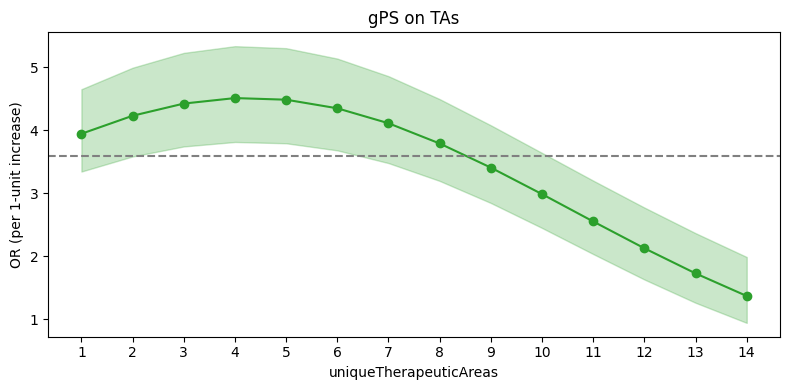

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(x, OR_ta, marker="o", color="tab:green", label="local OR (per 1-unit increase)")
plt.fill_between(x, OR_low_ta, OR_high_ta, color="tab:green", alpha=0.25)
plt.axhline(np.exp(gs_b), color="gray", linestyle="--")
plt.xticks(x)
plt.xlabel("uniqueTherapeuticAreas")
plt.ylabel("OR (per 1-unit increase)")
plt.title("gPS on TAs")
plt.tight_layout()
plt.show()


In [22]:
df = df_for_regression.copy()
model = smf.logit("outcome ~ geneticSupport+uniqueDiseases+I(uniqueDiseases ** 2)", data=df).fit(disp=False)

gs = "geneticSupport"
lin = "uniqueDiseases"
quad = "I(uniqueDiseases ** 2)"

gs_b = model.params[gs]
b1 = model.params[lin]
b2 = model.params[quad]
cov = model.cov_params().loc[[gs, lin, quad], [gs, lin, quad]]

x = np.arange(1, max_gps + 1)
gs_parameter = 1

log_or = gs_b * gs_parameter + b1 * x + b2 * (x**2)

V = cov.values
vecs = np.column_stack([np.full_like(x, gs_parameter, dtype=float), x.astype(float), (x**2).astype(float)])
se2 = np.sum((vecs @ V) * vecs, axis=1)  # shape (len(x),)
se_log_or = np.sqrt(np.maximum(se2, 0.0))

z = 1.96
OR_gps = np.exp(log_or)
OR_low_gps = np.exp(log_or - z * se_log_or)
OR_high_gps = np.exp(log_or + z * se_log_or)


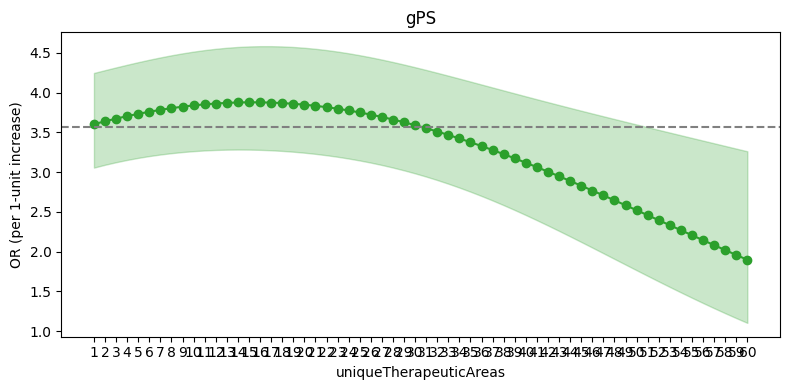

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(x, OR_gps, marker="o", color="tab:green", label="local OR (per 1-unit increase)")
plt.fill_between(x, OR_low_gps, OR_high_gps, color="tab:green", alpha=0.25)
plt.axhline(np.exp(gs_b), color="gray", linestyle="--")
plt.xticks(x)
plt.xlabel("uniqueTherapeuticAreas")
plt.ylabel("OR (per 1-unit increase)")
plt.title("gPS")
plt.tight_layout()
plt.show()


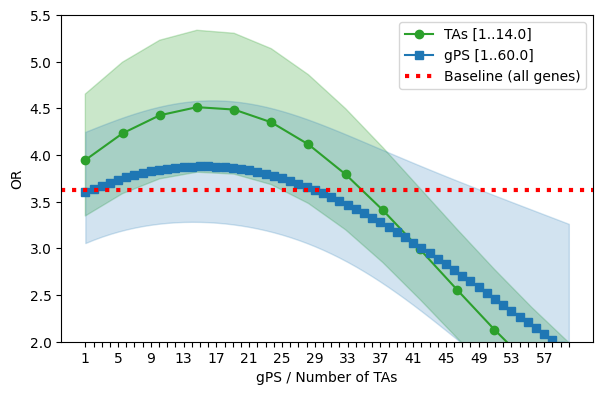

In [112]:
import matplotlib.pyplot as plt
import numpy as np

x_ta = np.arange(1, max_ta + 1)
x_gps = np.arange(1, max_gps + 1)
common_max = max(len(x_ta), len(x_gps))


def mapped_positions(x, common_max):
    if x.size == 1:
        return np.array([1.0])
    return 1.0 + (x - 1.0) * (common_max - 1.0) / (x[-1] - 1.0)


pos_ta = mapped_positions(x_ta, common_max)
pos_gps = mapped_positions(x_gps, common_max)

plt.figure(figsize=(6, 4))
# therapeutic areas
plt.plot(pos_ta, OR_ta, marker="o", color="tab:green", label=f"TAs [1..{x_ta[-1]}]")
plt.fill_between(pos_ta, OR_low_ta, OR_high_ta, color="tab:green", alpha=0.25)

# diseases
plt.plot(pos_gps, OR_gps, marker="s", color="tab:blue", label=f"gPS [1..{x_gps[-1]}]")
plt.fill_between(pos_gps, OR_low_gps, OR_high_gps, color="tab:blue", alpha=0.2)

plt.axhline(3.62, color="red", linestyle=":", linewidth=3, label="Baseline (all genes)")

# ticks: show integer bin positions for the common axis
ticks = np.arange(1, common_max + 1)
step = 4  # show every 2nd label; use 3 for every third, etc.
tick_labels = [str(i) if (i % step == 1) else "" for i in ticks]  # shows 1,3,5,...
plt.xticks(ticks, tick_labels)

plt.xlabel("gPS / Number of TAs")
plt.ylabel("OR")
plt.legend()
# plt.title("Predicted vs observed drug approval OR by gPS bins")
plt.tight_layout()
plt.ylim(2, 5.5)
plt.show()


In [88]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

df = df_for_regression.copy()

cats = sorted(df["bin_gps"].unique())
results = []

for cat in cats:
    if cat <= 0:
        continue
    # new column: geneticSupport only for rows in this category, 0 otherwise
    colname = f"gs_bin_{int(cat) if float(cat).is_integer() else str(cat).replace('.', '_')}"
    df[colname] = np.where(df["bin_gps"] == cat, df["geneticSupport"], 0)

    n_in_bin = int((df["bin_gps"] == cat).sum())

    mmin = df[df["bin_gps"] == cat]["uniqueDiseases"].min()
    mmax = df[df["bin_gps"] == cat]["uniqueDiseases"].max()
    if mmin == mmax:
        av_bin = mmin
    else:
        av_bin = mmin + (mmax - mmin) / 2

    # require variation in predictor and outcome
    if df[colname].nunique() < 2 or df["outcome"].nunique() < 2:
        results.append(
            {
                "bin_gps": cat,
                "n_in_bin": n_in_bin,
                "coef": np.nan,
                "OR": np.nan,
                "OR_low": np.nan,
                "OR_high": np.nan,
                "status": "no_variation",
            }
        )
        continue

    try:
        model = smf.logit(f"outcome ~ {colname}", data=df).fit(disp=False)
        coef = model.params[colname]
        ci_low, ci_high = model.conf_int().loc[colname].astype(float)
        OR = float(np.exp(coef))
        OR_low = float(np.exp(ci_low))
        OR_high = float(np.exp(ci_high))
        results.append(
            {
                "bin_gps": cat,
                "n_in_bin": n_in_bin,
                "coef": float(coef),
                "OR": OR,
                "OR_low": OR_low,
                "OR_high": OR_high,
                "av_bin": av_bin,
            }
        )
    except Exception as e:
        results.append(
            {
                "bin_mean_gps": cat,
                "n_in_bin": n_in_bin,
                "coef": np.nan,
                "OR": np.nan,
                "OR_low": np.nan,
                "OR_high": np.nan,
                "status": f"error: {str(e)}",
            }
        )

res_df = pd.DataFrame(results).sort_values("bin_gps").reset_index(drop=True)
res_df


,bin_gps,n_in_bin,coef,OR,OR_low,OR_high,av_bin
0,1.0,5724,1.464837,4.326837,2.410094,7.767962,1.0
1,2.0,2245,1.742451,5.711322,3.126098,10.434479,2.5
2,3.0,3327,1.431600,4.185390,2.723055,6.433026,3.5
3,4.0,4382,1.332873,3.791923,2.858055,5.030931,7.0
4,5.0,2802,1.062355,2.893176,2.284814,3.663522,35.0


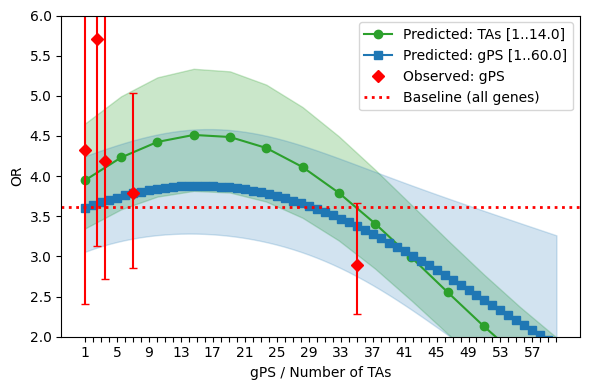

In [ ]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np

x_ta = np.arange(1, max_ta + 1)
x_gps = np.arange(1, max_gps + 1)
common_max = max(len(x_ta), len(x_gps))


def mapped_positions(x, common_max):
    if x.size == 1:
        return np.array([1.0])
    return 1.0 + (x - 1.0) * (common_max - 1.0) / (x[-1] - 1.0)


pos_ta = mapped_positions(x_ta, common_max)
pos_gps = mapped_positions(x_gps, common_max)

plt.figure(figsize=(6, 4))
# therapeutic areas
plt.plot(pos_ta, OR_ta, marker="o", color="tab:green", label=f"Predicted: TAs [1..{x_ta[-1]}]")
plt.fill_between(pos_ta, OR_low_ta, OR_high_ta, color="tab:green", alpha=0.25)

# diseases
plt.plot(pos_gps, OR_gps, marker="s", color="tab:blue", label=f"Predicted: gPS [1..{x_gps[-1]}]")
plt.fill_between(pos_gps, OR_low_gps, OR_high_gps, color="tab:blue", alpha=0.2)

# add observed points: third group of five from rest_df (use res_df if rest_df undefined)
try:
    obs_df = res_df
except NameError:
    obs_df = globals().get("res_df", None) or globals().get("res_df", None)

if obs_df is not None:
    obs_chunk = obs_df.reset_index(drop=True)
    if len(obs_chunk) > 0:
        x_obs = obs_chunk["av_bin"].to_numpy()
        # map x positions to common axis
        x_obs_mapped = x_obs
        y_obs = obs_chunk["OR"].to_numpy()
        y_low = obs_chunk["OR_low"].to_numpy()
        y_high = obs_chunk["OR_high"].to_numpy()
        # plot observed points and CI band in red
        plt.plot(x_obs_mapped, y_obs, marker="D", color="red", linestyle="", label="Observed: gPS")
        # plt.fill_between(x_obs_mapped, y_low, y_high, color="red", alpha=0.25)
        # optional vertical errorbars
        plt.errorbar(x_obs_mapped, y_obs, yerr=[y_obs - y_low, y_high - y_obs], fmt="none", ecolor="red", capsize=3)
    else:
        print("observed chunk (third five) is empty; nothing plotted for observed.")
else:
    print("res_df / res_df not found in namespace; cannot plot observed points.")

plt.axhline(3.62, color="red", linestyle=":", linewidth=2, label="Baseline (all genes)")

# ticks: show integer bin positions for the common axis
ticks = np.arange(1, common_max + 1)
step = 4  # show every 2nd label; use 3 for every third, etc.
tick_labels = [str(i) if (i % step == 1) else "" for i in ticks]  # shows 1,3,5,...
plt.xticks(ticks, tick_labels)

plt.xlabel("gPS / Number of TAs")
plt.ylabel("OR")
plt.ylim(2, 6)
plt.legend()
# plt.title("Predicted vs observed drug approval OR by gPS bins")
plt.tight_layout()
plt.show()
